In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
try:
    import catboost as cb
except:
    ! pip install catboost
    import catboost as cb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 31.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 8.5 MB/s eta 0:00:00


### Constants

In [2]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_dirname_output = './output'
flt_threshold = 0.80
int_n_rounds = 100
str_eval_metric = 'AUC'

str_id = 'uniqueid'
str_datecol = 'applicationdate__app'
str_target = 'target'

list_cols_id = [
    str_id,
    str_datecol,
    str_target,
    'dealerstampcreation__app',
]

Project: 20231010-gen-xii


### Output

In [3]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Get features missing ```>=``` threshold of proportion ```NaN```

In [4]:
# rm via prop nan threshold
list_cols_nan = []
for str_df in tqdm (['train','valid','test']):
    # import descriptives
    str_filename = f'df_descriptives_{str_df}.csv'
    str_local_path = f'../../04_eda_pt_2/output/{str_filename}'
    df = pd.read_csv(str_local_path)
    # subset
    df_tmp = df[df['propna'] >= flt_threshold].copy()
    # get features
    list_cols = list(df_tmp['feature'])
    # extend
    list_cols_nan.extend(list_cols)

# rm dups
list_cols_nan = list(dict.fromkeys(list_cols_nan))
# make sure certain features are not in the list
list_cols_ignore = [
    'intopenbktype__app',
]
list_cols_nan = [col for col in list_cols_nan if col not in list_cols_ignore]
print(f'There are {len(list_cols_nan)} features missing in at least {flt_threshold} proportion of rows')

100%|██████████| 3/3 [00:00<00:00, 91.32it/s]

There are 604 features missing in at least 0.8 proportion of rows


### Get features with all nan, no variance, or redundancy in train, valid, or test

In [5]:
%%time

# import
str_filename = 'df_cols_drop.csv'
str_local_path = f'../01_nan_novar_redundancy/output/{str_filename}'
df = pd.read_csv(str_local_path)

# get list
list_cols_allnan_novar_red = list(df['feature'])
print(f'There were {len(list_cols_allnan_novar_red)} with all nan, no var, or redundancy in train, valid, or test')
print('')

There were 402 with all nan, no var, or redundancy in train, valid, or test

CPU times: user 1.58 ms, sys: 153 µs, total: 1.73 ms
Wall time: 1.46 ms


### Get features identified as problematic by name

In [6]:
%%time

str_filename = 'df_cols_drop.csv'
str_local_path = f'../02_name/output/{str_filename}'
df = pd.read_csv(str_local_path)

# get list
list_cols_name = list(df['feature'])
print(f'There were {len(list_cols_name)} features identified as problematic by name')
print('')

There were 338 features identified as problematic by name

CPU times: user 1.35 ms, sys: 0 ns, total: 1.35 ms
Wall time: 1.22 ms


### Combine the lists

In [7]:
%%time

list_cols_bad = list_cols_nan + list_cols_allnan_novar_red + list_cols_name
# rm dups
list_cols_bad = list(dict.fromkeys(list_cols_bad))
print(f'There are {len(list_cols_bad)} bad features')
print('')

There are 925 bad features

CPU times: user 360 µs, sys: 0 ns, total: 360 µs
Wall time: 287 µs


### Get a list of all columns and make sure ```target``` is in the list

In [8]:
%%time

# import descriptives
str_filename = f'df_descriptives_train.csv'
str_local_path = f'../../04_eda_pt_2/output/{str_filename}'
df = pd.read_csv(str_local_path)
# get features
list_cols = list(df['feature'])

# rm leaky features
list_cols = [col for col in list_cols if col not in list_cols_bad]

# append target
list_cols.append(str_target)

# rm dups
list_cols = list(dict.fromkeys(list_cols))

# message
print(f'There are {len(list_cols)-1} features that will be checked for leakiness')
print('')

There are 1564 features that will be checked for leakiness

CPU times: user 30.2 ms, sys: 0 ns, total: 30.2 ms
Wall time: 30 ms


### Import training data

In [9]:
%%time

str_filename = 'df_train_raw.gzip'
str_uri = f's3://{str_project}/02_pricing_pd/01_data_prep/03_train_valid_test_split/{str_filename}'
df_train = pd.read_parquet(str_uri, columns=list_cols)

# sample
df_train = df_train.sample(frac=0.01, random_state=42)

# replace
df_train.replace(['NaN','nan'], np.nan, inplace=True)

# get non numeric
list_cols_non_numeric = []
for col in df_train.columns:
    if df_train[col].dtype not in ['float64','int64']:
        list_cols_non_numeric.append(col)
# set as string
df_train[list_cols_non_numeric] = df_train[list_cols_non_numeric].astype(str)

# fillna
df_train.fillna(0, inplace=True)

# show
df_train

CPU times: user 5.29 s, sys: 12.8 s, total: 18.1 s
Wall time: 1.62 s


,linkf060__tu,linkf045__tu,linkf185__tu,linkf193__tu,linkf105__tu,linkf195__tu,linkf032__tu,linkf083__tu,linkf084__tu,linkf078__tu,...,bitdealerapplicantsamezip__app,fltallowance__app,dealerstate__app,inttermbump__app,bitdealertrack__app,bitrouteone__app,bigdealertypeid__app,intservicecontractmileageaddon__app,bitmaintenanceagreement__app,target
79720,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,...,0.0,0.0,Oregon,0.0,1.0,0.0,1.0,24000.0,0.0,0
87411,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,...,0.0,500.0,Ohio,6.0,0.0,1.0,1.0,36000.0,0.0,0
127802,0.0,0.0,213.0,213.0,213.0,217.0,N,0.0,0.0,0.0,...,0.0,0.0,Maryland,0.0,1.0,0.0,1.0,0.0,0.0,0
40165,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,...,0.0,0.0,New Jersey,6.0,0.0,1.0,5.0,36000.0,0.0,0
90822,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,...,0.0,0.0,Kentucky,0.0,1.0,0.0,1.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92833,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,...,0.0,0.0,Maryland,0.0,1.0,0.0,1.0,0.0,0.0,0
113669,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,...,0.0,0.0,Colorado,6.0,1.0,0.0,1.0,36000.0,0.0,1
93183,0.0,0.0,1697.0,1338.0,1052.0,1697.0,N,0.0,0.0,0.0,...,0.0,0.0,Alabama,0.0,1.0,0.0,1.0,0.0,0.0,0
111223,0.0,0.0,466.0,466.0,466.0,466.0,N,0.0,0.0,0.0,...,0.0,0.0,Washington,0.0,1.0,0.0,1.0,0.0,0.0,0


### Import validation data

In [10]:
%%time

str_filename = 'df_valid_raw.gzip'
str_uri = f's3://{str_project}/02_pricing_pd/01_data_prep/03_train_valid_test_split/{str_filename}'
df_valid = pd.read_parquet(str_uri, columns=list_cols)

# sample
df_valid = df_valid.sample(frac=0.01, random_state=42)

# replace
df_valid.replace(['NaN','nan'], np.nan, inplace=True)

# set as string
df_valid[list_cols_non_numeric] = df_valid[list_cols_non_numeric].astype(str)

# fillna
df_valid.fillna(0, inplace=True)

# show
df_valid

CPU times: user 2.16 s, sys: 1.83 s, total: 3.98 s
Wall time: 927 ms


<timed exec>:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


,linkf060__tu,linkf045__tu,linkf185__tu,linkf193__tu,linkf105__tu,linkf195__tu,linkf032__tu,linkf083__tu,linkf084__tu,linkf078__tu,...,bitdealerapplicantsamezip__app,fltallowance__app,dealerstate__app,inttermbump__app,bitdealertrack__app,bitrouteone__app,bigdealertypeid__app,intservicecontractmileageaddon__app,bitmaintenanceagreement__app,target
160729,0.0,0.0,639.0,351.0,262.0,1751.0,N,0.0,0.0,2.0,...,0.0,0.0,Illinois,6.0,1.0,0.0,2.0,0.0,0.0,1
155143,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,...,0.0,0.0,Tennessee,6.0,1.0,0.0,1.0,0.0,0.0,0
177559,0.0,0.0,786.0,786.0,786.0,786.0,N,0.0,0.0,0.0,...,0.0,0.0,Oklahoma,0.0,1.0,0.0,1.0,0.0,0.0,0
160853,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,...,0.0,0.0,Ohio,6.0,1.0,0.0,2.0,0.0,0.0,0
161738,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,...,0.0,4000.0,Tennessee,6.0,1.0,0.0,1.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166371,0.0,0.0,0.0,202.0,13.0,202.0,N,0.0,0.0,1.0,...,0.0,0.0,Colorado,6.0,1.0,0.0,1.0,0.0,0.0,0
159223,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,...,0.0,0.0,California,0.0,1.0,0.0,1.0,0.0,0.0,0
152021,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,...,0.0,0.0,Kentucky,0.0,0.0,1.0,1.0,0.0,0.0,0
171842,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,...,0.0,0.0,Florida,0.0,1.0,0.0,1.0,0.0,0.0,0


### List of columns to check for leakiness

In [11]:
%%time

# columns to check for drift
list_cols_model = [col for col in list_cols if col not in list_cols_id]
print(f'After ensuring no ID columns nor the target are in the model, there are {len(list_cols_model)} columns to check for leakiness')
print('')

After ensuring no ID columns nor the target are in the model, there are 1563 columns to check for leakiness

CPU times: user 168 µs, sys: 282 µs, total: 450 µs
Wall time: 367 µs


### Iterate, build models, and remove the top feature

In [12]:
%%time

# build models and remove the top feature
list_feats_checked = []
list_dict_row = []
for a in tqdm(range(int_n_rounds), total=int_n_rounds, desc='Building Models'):
    # new list
    list_cols_tmp = [col for col in list_cols_model if col not in list_feats_checked]
    
    # get non numeric
    list_cols_non_numeric = []
    for col in list_cols_tmp:
        if df_train[col].dtype not in ['float64','int64']:
            list_cols_non_numeric.append(col)
    
    # train
    pool_train = cb.Pool(
        df_train[list_cols_tmp], 
        df_train[str_target], 
        cat_features=list_cols_non_numeric,
    )
    # valid
    pool_valid = cb.Pool(
        df_valid[list_cols_tmp], 
        df_valid[str_target], 
        cat_features=list_cols_non_numeric,
    )
    
    # init class
    cls_model_inference = cb.CatBoostClassifier(
        task_type='CPU',
        nan_mode='Min',
        random_state=42,
        eval_metric=str_eval_metric,
        iterations=100,
        monotone_constraints=None,
        class_weights=None,
    )
    
    # fit
    cls_model_inference.fit(
        pool_train,
        eval_set=[pool_valid],
        verbose=False,
        use_best_model=True,
        early_stopping_rounds=10, 
    )
    
    # get most important feature
    df_imp = pd.DataFrame({
        'feature': list(cls_model_inference.feature_names_),
        'importance': list(cls_model_inference.get_feature_importance()),
    })
    df_imp.sort_values(by='importance', ascending=False, inplace=True)
    
    # make dict
    dict_row = {
        'iteration': a+1,
        'feature': df_imp['feature'].iloc[0],
        'importance': df_imp['importance'].iloc[0],
        'train_score': cls_model_inference.get_best_score()['learn']['Logloss'],
        'valid_score': cls_model_inference.get_best_score()['validation']['Logloss'],
        'best_iteration': cls_model_inference.get_best_iteration(),
    }
    list_dict_row.append(dict_row)
    
    # make df
    df_dict_row = pd.DataFrame(list_dict_row)
    list_feats_checked = list(df_dict_row['feature'])

Building Models: 100%|██████████| 100/100 [02:00<00:00,  1.21s/it]

CPU times: user 1h 35min 27s, sys: 5min 9s, total: 1h 40min 36s
Wall time: 2min


### View df

In [13]:
# show
df_dict_row

,iteration,feature,importance,train_score,valid_score,best_iteration
0,1,g001c__tu,7.176349,0.301337,0.338192,11
1,2,addrlastmovetaxratiodiff__ln,21.386008,0.349438,0.362687,1
2,3,addrinputtaxvalue__ln,4.794126,0.261650,0.336409,25
3,4,linka024__tu,32.516114,0.345792,0.368752,1
4,5,index01__tu,40.225664,0.368037,0.374556,0
...,...,...,...,...,...,...
95,96,s204s__tu,3.340400,0.212562,0.337879,56
96,97,bc106s__tu,15.491056,0.356190,0.371739,1
97,98,fi36s__tu,4.656146,0.266115,0.336251,22
98,99,in28s__tu,4.055226,0.277704,0.337353,19


### Plot scores by iteration

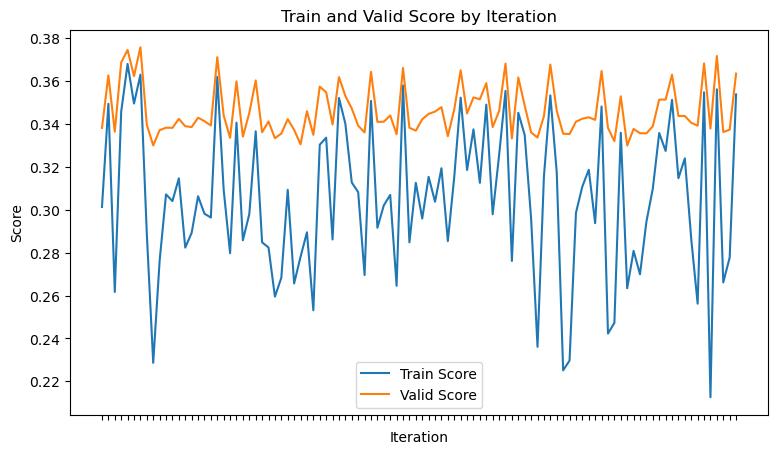

In [14]:
# plot
#int_n_features = 15
#int_n_features_drop = 46
fig, ax = plt.subplots(figsize=(9,5))
str_title = 'Train and Valid Score by Iteration'
ax.set_title(str_title)
ax.set_xlabel('Iteration')
ax.set_xticklabels([])
ax.set_ylabel('Score')
ax.plot(df_dict_row['iteration'].astype(str), df_dict_row['train_score'], label='Train Score')
ax.plot(df_dict_row['iteration'].astype(str), df_dict_row['valid_score'], label='Valid Score')
#ax.axvline(x=int_n_features, color='red', linestyle='--', label=f'{int_n_features} Features')
#ax.axvline(x=int_n_features_drop, color='black', linestyle='--', label=f'{int_n_features_drop} Features')
# legend
plt.legend()

# save
str_filename = 'plt_score_by_iteration.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

### Tag as leaky or not

In [15]:
# %%time

# # tag as leaky
# df_dict_row['leaky'] = df_dict_row['iteration'].apply(
#     lambda x: 1 if x <= int_n_features else 0,
# )

# # show
# df_dict_row.head(int_n_features+5)

### Save df

In [16]:
%%time

str_filename = 'df_leaky_models.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_dict_row.to_csv(str_local_path, index=False)

CPU times: user 2.06 ms, sys: 116 µs, total: 2.17 ms
Wall time: 2.03 ms


### Tag and save df

In [17]:
%%time

# make list
#list_cols_leaky = list(df_dict_row['feature'])[:int_n_features]

# combine lists
#list_cols_bad = list_cols_bad + list_cols_leaky
# rm dups
list_cols_bad = list(dict.fromkeys(list_cols_bad))

# make df
df = pd.DataFrame({'feature': list_cols_bad})

# tag
df['from_nan'] = df['feature'].apply(
    lambda x: 1 if x in list_cols_nan else 0,
)

# tag
df['from_df'] = df['feature'].apply(
    lambda x: 1 if x in list_cols_allnan_novar_red else 0,
)

# tag
df['from_name'] = df['feature'].apply(
    lambda x: 1 if x in list_cols_name else 0,
)

# # tag
# df['from_models'] = df['feature'].apply(
#     lambda x: 1 if x in list_cols_leaky else 0,
# )

# sum
list_cols = [
    'from_nan',
    'from_df',
    'from_name',
    #'from_models'
]
df['sum'] = df[list_cols].sum(axis=1)

# sort
df.sort_values(by='sum', ascending=False, inplace=True)

# save
str_filename = 'df_cols_bad.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_local_path, index=False)

# show
df

CPU times: user 19 ms, sys: 33 µs, total: 19.1 ms
Wall time: 18.4 ms


,feature,from_nan,from_df,from_name,sum
0,dtmstampcreation__base,1,1,1,3
27,permid__tu,1,1,1,3
29,acctid__tu,1,1,1,3
546,dtmapproved__tu,1,1,1,3
99,bitsystemdecline__app,1,1,1,3
...,...,...,...,...,...
84,linkb014__tu,1,0,0,1
85,linkb013__tu,1,0,0,1
86,linkb005__tu,1,0,0,1
87,linkb015__tu,1,0,0,1
